# ADC Target Feature Engineering

**v0.1 educational notebook**

## Goal
Integrate expression, HPA-style safety, and surface annotation into the canonical ADC target feature matrix.

**Data mode:** Executable example using outputs from Notebooks 02–03 and a small example annotation file.

## Canonical guide

### Learning objectives
- Integrate transcriptomic, protein-safety, and surface evidence.
- Create benefit, risk, eligibility, and missingness features.
- Freeze the canonical target-level feature matrix for downstream ranking models.

### Data mode
Derived from the synthetic/public-data-style outputs of Notebooks 02–03 plus a compact example surface annotation file.

### Inputs
`outputs/tcga_gtex_expression_features.csv`, `outputs/hpa_normal_tissue_features.csv`, `data/example/surface_gene_annotation.csv`

### Canonical outputs
`outputs/adc_target_feature_matrix_v01.csv`

### Scientific limitation
The surface score is an educational annotation, not a direct measurement of extracellular epitope accessibility or receptor density.

### Next step
Notebook 05 creates and stress-tests a transparent rule-based ranking baseline.


In [1]:
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data'
OUTPUTS = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
print('ROOT:', ROOT.resolve())

ROOT: /mnt/data/audit_adc/adc-scientific-ai


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
expr=pd.read_csv(OUTPUTS/'tcga_gtex_expression_features.csv',index_col=0)
hpa=pd.read_csv(OUTPUTS/'hpa_normal_tissue_features.csv',index_col=0)
surface=pd.read_csv(DATA/'example'/'surface_gene_annotation.csv').set_index('gene_symbol')
features=expr.join(hpa,how='inner').join(surface,how='left')
features['surface_missing']=features.surface_score.isna()
features['surface_eligible']=features.surface_score.ge(0.5)
print(features.shape)

(24, 21)


In [3]:
def robust_minmax(s,lower_q=.01,upper_q=.99):
    s=s.astype(float); lo=s.quantile(lower_q); hi=s.quantile(upper_q); c=s.clip(lo,hi)
    return pd.Series(0.5,index=s.index) if hi==lo else (c-lo)/(hi-lo)
features['tumor_score']=robust_minmax(features.tumor_median)
features['selectivity_score']=robust_minmax(features.delta_expression)
features['prevalence_score']=features.tumor_prevalence.clip(0,1)
features['surface_score_norm']=features.surface_score.clip(0,1)
features['heterogeneity_risk']=robust_minmax(features.tumor_iqr)
features['normal_rna_risk']=robust_minmax(features.normal_median)
features['normal_protein_risk_norm']=features.normal_protein_risk.clip(0,1)
features['critical_organ_risk']=(features.critical_organ_max/3).clip(0,1)
core=['tumor_score','selectivity_score','prevalence_score','surface_score_norm','heterogeneity_risk','normal_rna_risk','normal_protein_risk_norm','critical_organ_risk']
features['scorable']=features[core].notna().all(axis=1)
features.head()

,tumor_mean,tumor_median,tumor_sd,tumor_iqr,normal_mean,normal_median,delta_expression,tumor_prevalence,normal_prevalence,hpa_normal_max,n_normal_tissues_positive,normal_tissue_fraction_positive,n_normal_celltypes_positive,critical_organ_max,n_critical_tissues_positive,normal_protein_risk,hpa_missing,surface_score,surface_confidence,surface_missing,surface_eligible,tumor_score,selectivity_score,prevalence_score,surface_score_norm,heterogeneity_risk,normal_rna_risk,normal_protein_risk_norm,critical_organ_risk,scorable
gene_symbol,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ERBB2,9.031177,8.929292,0.965318,1.329676,0.567109,0.558175,8.371116,1.0000,0.0,2,4,0.500,1,2,3,0.633333,False,1.0,high,False,True,0.916993,1.000000,1.0000,1.0,0.053299,0.035680,0.633333,0.666667,True
TACSTD2,7.971553,7.896318,1.227710,1.586680,0.496157,0.394122,7.502196,1.0000,0.0,3,3,0.375,1,3,3,0.875000,False,1.0,high,False,True,0.770703,0.905579,1.0000,1.0,0.120905,0.000000,0.875000,1.000000,True
NECTIN4,9.453648,9.346846,1.267520,1.370431,0.997754,1.074437,8.272409,1.0000,0.0,3,7,0.875,1,3,4,0.975000,False,1.0,high,False,True,0.976128,0.991519,1.0000,1.0,0.064020,0.181500,0.975000,1.000000,True
FOLR1,9.435146,9.565760,1.150617,1.648689,1.363935,1.373991,8.191769,1.0000,0.0,3,3,0.375,1,3,2,0.875000,False,1.0,high,False,True,1.000000,0.982522,1.0000,1.0,0.137217,0.266111,0.875000,1.000000,True
EPCAM,2.497228,2.556193,1.238309,1.465133,0.882344,0.732755,1.823439,0.1125,0.0,2,7,0.875,1,2,4,0.708333,False,1.0,high,False,True,0.014430,0.271941,0.1125,1.0,0.088932,0.084991,0.708333,0.666667,True


In [4]:
features['benefit_score']=0.25*features.tumor_score+0.30*features.selectivity_score+0.25*features.prevalence_score+0.20*features.surface_score_norm
features['risk_score']=0.35*features.normal_protein_risk_norm+0.30*features.critical_organ_risk+0.20*features.normal_rna_risk+0.15*features.heterogeneity_risk
features['adc_target_score_raw']=features.benefit_score-features.risk_score
features['passes_hard_filters']=features.surface_score.ge(.5)&features.tumor_prevalence.ge(.20)&features.critical_organ_max.le(2)
path=OUTPUTS/'adc_target_feature_matrix_v01.csv'
features.to_csv(path)
print('saved:',path)

saved: /mnt/data/audit_adc/adc-scientific-ai/outputs/adc_target_feature_matrix_v01.csv


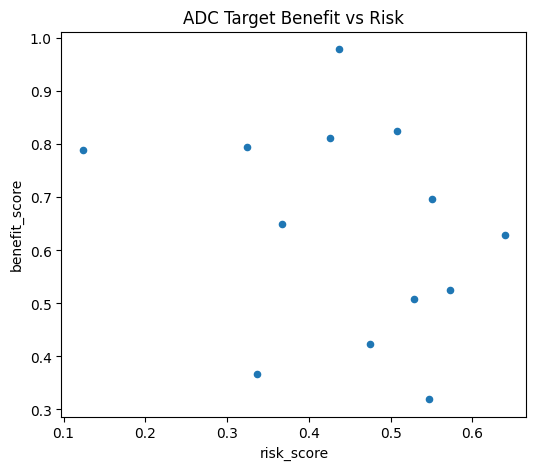

In [5]:
features.loc[features.passes_hard_filters].plot.scatter(x='risk_score',y='benefit_score',figsize=(6,5),title='ADC Target Benefit vs Risk')
plt.show()

## Take-home message
This notebook turns biological assumptions into a machine-learning-ready representation. Surface eligibility is treated as both evidence and a possible hard constraint; missing annotations are not silently converted to negatives.